## Outliers

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
arr1 = np.random.randint(20,60,size=(20))
arr1

array([54, 50, 35, 57, 52, 22, 54, 53, 53, 53, 50, 34, 40, 47, 45, 57, 23,
       43, 28, 31])

In [4]:
arr2 = np.array([35, 29, 49, 34, 38, 35, 53, 50, 53, 25, 47, 36, 26, 29, 49, 31, 33, 42, 245, 260])
arr2

array([ 35,  29,  49,  34,  38,  35,  53,  50,  53,  25,  47,  36,  26,
        29,  49,  31,  33,  42, 245, 260])

<Axes: ylabel='Density'>

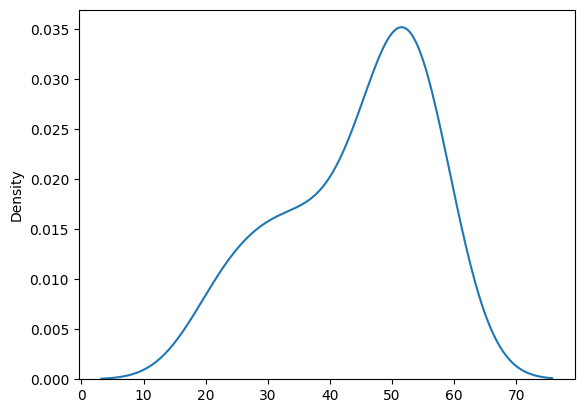

In [5]:
sns.kdeplot(arr1)

<Axes: ylabel='Density'>

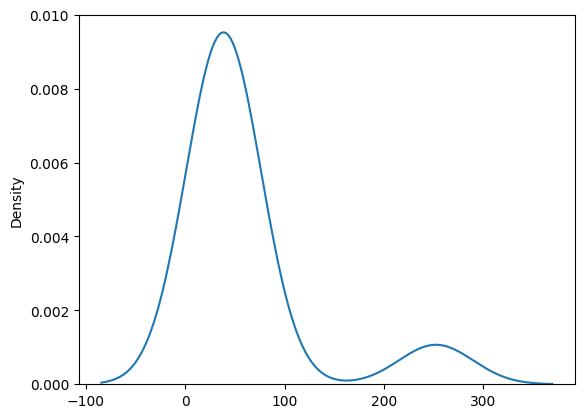

In [6]:
sns.kdeplot(arr2)

<Axes: >

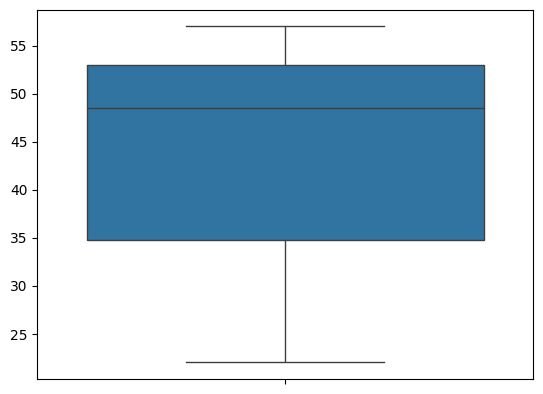

In [7]:
sns.boxplot(arr1)

<Axes: >

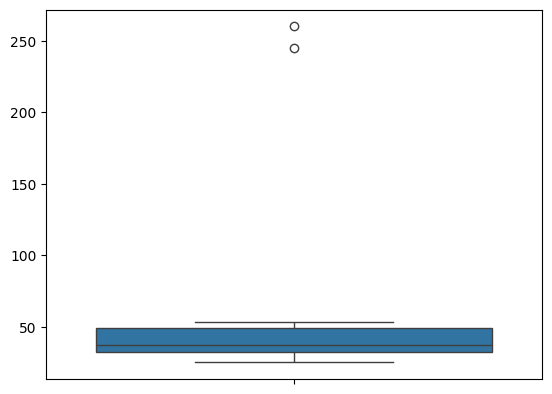

In [8]:
sns.boxplot(arr2)

In [9]:
from scipy.stats import skew, kurtosis

In [11]:
skew(arr1)

-0.6833640825160815

In [12]:
skew(arr2)

2.584298426012599

## 1. Z-score Method

When data distribution is normal
Most of the values lies around mean
std >> how far away a datapoint is from mean
z_Score >> how many std away a datapoint is from mean

Outlier Treatment:
    1. Trimming(drop)
    2. Capping (Impuation)

# Standardization

z_score = (X-X_mean)/std
x >> datapoint
x_mean >> mean values
std >> standard deviation

In [13]:
print(arr1)
mean = np.mean(arr1)
print(f'Mean == {mean}')

std = np.std(arr1)
print(f'Std == {std}')

[54 50 35 57 52 22 54 53 53 53 50 34 40 47 45 57 23 43 28 31]
Mean == 44.05
Std == 11.124185363432236


In [14]:
x = 45
z_score_x = (x - mean)/std
z_score_x

0.08539951187103301

In [15]:
x = 21
z_score_x = (x - mean)/std
z_score_x

-2.0720618406603206

In [16]:
x = 250
z_score_x = (x - mean)/std
z_score_x

18.513715231409677

In [17]:
print(arr1)
mean = np.mean(arr1)
print(f'Mean == {mean}')

std = np.std(arr1)
print(f'Std == {std}')

threshold = 3
outliers_list = []

for x_val in arr1:
    z_score = (x_val-mean)/std
    z_score = np.abs(z_score)
    print(f'{x_val} >> {z_score}')
    
    if z_score > threshold:
        outliers_list.append(x_val)
        
print('Outliers are :', outliers_list)

[54 50 35 57 52 22 54 53 53 53 50 34 40 47 45 57 23 43 28 31]
Mean == 44.05
Std == 11.124185363432236
54 >> 0.8944475190702906
50 >> 0.5348706269817317
35 >> 0.8135427183503644
57 >> 1.1641301881367099
52 >> 0.7146590730260112
22 >> 1.9821676176381808
54 >> 0.8944475190702906
53 >> 0.8045532960481508
53 >> 0.8045532960481508
53 >> 0.8045532960481508
50 >> 0.5348706269817317
34 >> 0.9034369413725041
40 >> 0.3640716032396657
47 >> 0.26518795791531247
45 >> 0.08539951187103301
57 >> 1.1641301881367099
23 >> 1.8922733946160413
43 >> 0.09438893417324647
28 >> 1.4428022795053426
31 >> 1.1731196104389232
Outliers are : []


In [19]:
print(arr2)
mean = np.mean(arr2)
print(f'Mean == {mean}')

std = np.std(arr2)
print(f'Std == {std}')

threshold = 3
outliers_list = []

for x_val in arr2:
    z_score = (x_val-mean)/std
    z_score = np.abs(z_score)
    print(f'{x_val} >> {z_score}')
    
    if z_score > threshold:
        outliers_list.append(x_val)
        
print('Outliers are :', outliers_list)

[ 35  29  49  34  38  35  53  50  53  25  47  36  26  29  49  31  33  42
 245 260]
Mean == 59.95
Std == 64.81394525871728
35 >> 0.384948021608734
29 >> 0.47752069213588444
49 >> 0.16894512371204962
34 >> 0.40037680002992576
38 >> 0.33866168634515875
35 >> 0.384948021608734
53 >> 0.10723001002728265
50 >> 0.15351634529085786
53 >> 0.10723001002728265
25 >> 0.5392358058206514
47 >> 0.1998026805544331
36 >> 0.36951924318754226
26 >> 0.5238070273994597
29 >> 0.47752069213588444
49 >> 0.16894512371204962
31 >> 0.44666313529350093
33 >> 0.4158055784511175
42 >> 0.2769465726603918
245 >> 2.855095446841532
260 >> 3.0865271231594082
Outliers are : [260]


29 = 59.95 - z * (64.81)
z = (29-59.95)/64.81

In [25]:
(29-59.95)/64.81

-0.47754976083937667

In [26]:
(245 -59.95)/64.81

2.855269248572751

In [20]:
print(arr2)
mean = np.mean(arr2)
print(f'Mean == {mean}')

std = np.std(arr2)
print(f'Std == {std}')

threshold = 2
outliers_list = []

for x_val in arr2:
    z_score = (x_val-mean)/std
    z_score = np.abs(z_score)
    print(f'{x_val} >> {z_score}')
    
    if z_score > threshold:
        outliers_list.append(x_val)
        
print('Outliers are :', outliers_list)

[ 35  29  49  34  38  35  53  50  53  25  47  36  26  29  49  31  33  42
 245 260]
Mean == 59.95
Std == 64.81394525871728
35 >> 0.384948021608734
29 >> 0.47752069213588444
49 >> 0.16894512371204962
34 >> 0.40037680002992576
38 >> 0.33866168634515875
35 >> 0.384948021608734
53 >> 0.10723001002728265
50 >> 0.15351634529085786
53 >> 0.10723001002728265
25 >> 0.5392358058206514
47 >> 0.1998026805544331
36 >> 0.36951924318754226
26 >> 0.5238070273994597
29 >> 0.47752069213588444
49 >> 0.16894512371204962
31 >> 0.44666313529350093
33 >> 0.4158055784511175
42 >> 0.2769465726603918
245 >> 2.855095446841532
260 >> 3.0865271231594082
Outliers are : [245, 260]


In [21]:
df = pd.read_csv('diabetes.csv')
df

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148,50,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
2,183,64,0,0,23.3,0.672,52,1
3,150,66,23,94,28.1,0.167,21,0
4,150,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...
763,101,76,48,180,32.9,0.171,63,0
764,122,70,27,0,36.8,0.340,27,0
765,121,72,23,112,26.2,0.245,30,0
766,126,60,0,0,30.1,0.349,47,1


<Axes: >

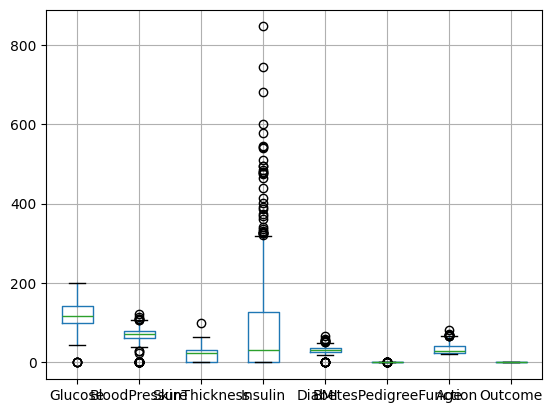

In [22]:
df.boxplot()

In [23]:
def get_outliers(feature):
    
    mean = feature.mean()
    print(f'Mean == {mean}')
    
    std = feature.std()
    print(f'Std == {std}')
    
    threshold = 3
    outliers_list = []

    for x_val in feature.values:
        z_score = (x_val-mean)/std
        z_score = np.abs(z_score)

        if z_score > threshold:
            print(f'{x_val} >> {z_score}')
            outliers_list.append(x_val)

    
get_outliers(df['Insulin'])

Mean == 79.79947916666667
Std == 115.24400235133817
543 >> 4.019302622111291
846 >> 6.648506691892384
495 >> 3.6027950467004253
485 >> 3.516022635156495
495 >> 3.6027950467004253
478 >> 3.4552819470757434
744 >> 5.7634280941442935
680 >> 5.208084660263139
545 >> 4.036657104420077
465 >> 3.3424778120686343
579 >> 4.331683303669441
474 >> 3.420572982458171
480 >> 3.4726364293845298
600 >> 4.513905367911695
440 >> 3.125546783208808
540 >> 3.9932708986481122
480 >> 3.4726364293845298
510 >> 3.732953664016321


In [26]:
import scipy.stats as ss
# from statsmodels.stats.ou
# print(dir(ss))

In [27]:
from scipy.stats import zscore

def get_outliers(feature):
    
    threshold = 3
    outliers_list = []
    
    z_score = zscore(feature)
    outliers_index = np.where(np.abs(z_score) > threshold)[0]
    print(outliers_index)
    
    print(feature.iloc[outliers_index])
    
get_outliers(df['Insulin'])

[  8  13 111 153 186 220 228 247 286 370 409 415 486 584 645 655 695 753]
8      543
13     846
111    495
153    485
186    495
220    478
228    744
247    680
286    545
370    465
409    579
415    474
486    480
584    600
645    440
655    540
695    480
753    510
Name: Insulin, dtype: int64


## 2. IQR (Inter Quartile Range)

Use when the data is not normally distributed

Boxplot:
    Median (50%ile/Q2):
        the middle value of the  dataset
        
    1st Quartile (Q1/25%ile):
        middle no between min and median
        
    3rd Quartile (Q3, 75%ile):
        middle no between median and max
        
IQR : 
    25% to 75%
    
    maximum = Q3 + 1.5 *IQR
    minimum = Q1 - 1.5 *IQR

In [28]:
df.describe()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,121.117188,69.076823,20.536458,79.799479,31.992578,0.471876,33.243490,0.348958
std,31.805091,19.367794,15.952218,115.244002,7.884160,0.331329,11.758182,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,142.000000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<Axes: xlabel='Insulin', ylabel='Density'>

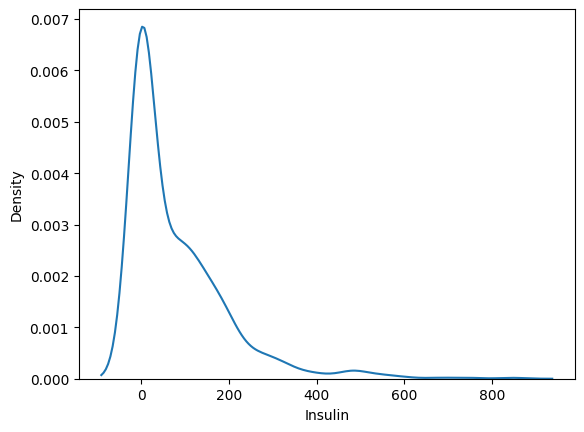

In [29]:
sns.kdeplot(df['Insulin'])

<Axes: xlabel='Insulin', ylabel='Count'>

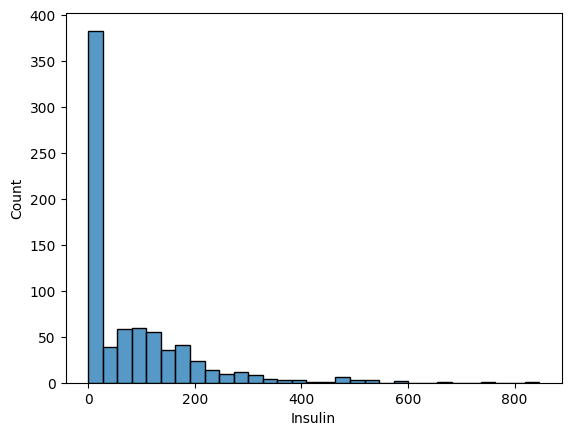

In [30]:
sns.histplot(df['Insulin'])

In [31]:
df['Glucose'].median()

117.0

In [32]:
df['Glucose'].quantile(0.5)

117.0

In [33]:
q1 = df['Glucose'].quantile(0.25)
q2 = df['Glucose'].quantile(0.5)
q3 = df['Glucose'].quantile(0.75)

print('Q1 == ', q1)
print('Q2 == ', q2)
print('Q3 == ', q3)

iqr = q3 - q1
print('IQR == ', iqr)

upper_tail = q3 + 1.5* iqr
lower_tail = q1 - 1.5* iqr

print('Upper Tail == ', upper_tail)
print('Lower Tail == ', lower_tail)

Q1 ==  99.0
Q2 ==  117.0
Q3 ==  142.0
IQR ==  43.0
Upper Tail ==  206.5
Lower Tail ==  34.5


In [48]:
df[df['Glucose'] < lower_tail]

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,0,48,20,0,24.7,0.140,22,0
182,0,74,20,23,27.7,0.299,21,0
342,0,68,35,0,32.0,0.389,22,0
349,0,80,32,0,41.0,0.346,37,1
502,0,68,41,0,39.0,0.727,41,1


In [49]:
df[df['Glucose'] > upper_tail]

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


<AxesSubplot:xlabel='Glucose'>

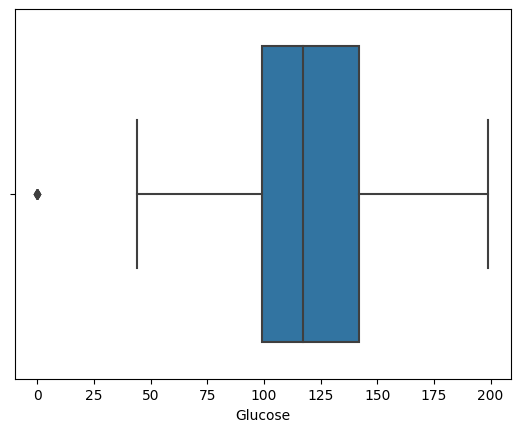

In [50]:
sns.boxplot(df['Glucose'])

In [36]:
df[(df['Glucose']< lower_tail) | (df['Glucose'] > upper_tail)]

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,0,48,20,0,24.7,0.140,22,0
182,0,74,20,23,27.7,0.299,21,0
342,0,68,35,0,32.0,0.389,22,0
349,0,80,32,0,41.0,0.346,37,1
502,0,68,41,0,39.0,0.727,41,1


In [37]:
q1 = df['Insulin'].quantile(0.25)
q2 = df['Insulin'].quantile(0.5)
q3 = df['Insulin'].quantile(0.75)

print('Q1 == ', q1)
print('Q2 == ', q2)
print('Q3 == ', q3)

iqr = q3 - q1
print('IQR == ', iqr)

upper_tail = q3 + 1.5* iqr
lower_tail = q1 - 1.5* iqr

print('Upper Tail == ', upper_tail)
print('Lower Tail == ', lower_tail)

Q1 ==  0.0
Q2 ==  30.5
Q3 ==  127.25
IQR ==  127.25
Upper Tail ==  318.125
Lower Tail ==  -190.875


In [38]:
df[(df['Insulin']< lower_tail) | (df['Insulin'] > upper_tail)].shape

(34, 8)